# 27c. Agent Eval Gates

**Tier:** Evaluation & Production
**Estimated time:** 60 minutes
**Prerequisites:** 24, 26, 27b
**Priority:** 🔴 Crucial — 27b taught you to *measure* an agent; this notebook makes measurements *do* something. A verdict that does not change what runs next is a report, not a gate — and almost nobody has a real gate because the evidence it would need does not exist yet in most systems. *If skipped, revisit when:* an agent's output ships anywhere a human does not re-check it before it lands.
**Source material:** Six-step agent eval-gate architecture — X (Twitter) thread, 2026 (exact author/URL not recovered by search; shared directly in conversation).

## What You'll Learn
- Why the score from an LLM judge is partly a measurement of the judge, and the three rules that keep a biased judge from being worse than no gate at all
- How to turn a verdict into a structural action on the run in progress (reject a handoff, block an edge, quarantine a branch, end a run) instead of a number on a dashboard
- Three levels of agent grading — end-to-end, trajectory, component — and why grading only the final answer misses failures that hide in a clean-looking report
- How to mine your own traces for eval cases instead of inventing tests at a desk, and how to verify a verifier before trusting it
- Why judges need a pinned version stamped on every score, and why blast radius (not confidence) is the right variable to gate a merge on

## Why This Matters
Notebook 27b built the measuring instruments: trajectory scoring, tool-call correctness, a task suite, cost-per-solved-task. Its own Exercise 3 sketched a CI regression gate but stopped at the sketch. This notebook builds the gate itself — the decision layer that reads those measurements as evidence and decides, structurally, what an agent-produced change is allowed to do next. The honest version of what you are building is not trust in the agent; it is a constraint tight enough that trust stops being the question.

In [1]:
import os, sys, re, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"

if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready.")
else:
    client = None
    print("No ANTHROPIC_API_KEY -- live judge calls will be skipped; every gate/pipeline/mining cell below runs on canned data regardless.")

def ask(prompt, system="You are concise.", max_tokens=200, temperature=0.0):
    if not HAS_ANTHROPIC:
        return "[skipped: no ANTHROPIC_API_KEY]"
    try:
        msg = client.messages.create(model=TEACH_MODEL, max_tokens=max_tokens, system=system,
                                      temperature=temperature, messages=[{"role": "user", "content": prompt}])
        return msg.content[0].text
    except Exception as e:
        return f"[skipped: {type(e).__name__}: {str(e)[:120]}]"

def find_repo_root(marker="pyproject.toml", start=None):
    # search upward for the repo root -- cwd differs between notebooks.sh (repo root)
    # and opening this notebook directly in Jupyter (05_evaluation/). See 20b's helper.
    here = Path(start or ".").resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    return here

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

from agentkit import (
    Action, BlastRadius, Evidence, EvidenceSource, GateDecision, JudgeConfig,
    LanePolicy, MergeGate, Verdict, cross_family_warnings, judge_verdict, verdict_to_action,
)
from agentkit.contracts import contracts_from_schemas, validate_args
print("agentkit.gates imported:", MergeGate, BlastRadius.IRREVERSIBLE)

No ANTHROPIC_API_KEY -- live judge calls will be skipped; every gate/pipeline/mining cell below runs on canned data regardless.
agentkit.gates imported: <class 'agentkit.gates.MergeGate'> BlastRadius.IRREVERSIBLE


## A. The agent under test (recap of notebook 27b)

To gate an agent's work you need an agent producing work. This is the same minimal tool-using agent from notebook 27b (`_KB`, `search_docs`, `calculator`, `run_agent`, `trajectory_score`, `tool_call_correctness`) -- skim it there if any of it looks unfamiliar; it is reproduced here only because notebooks in this curriculum are self-contained.

The one addition: `CANNED_RUNS`, four recorded agent outputs (good / ungrounded / schema-violating / fabricated-completion) that stand in for real production traces. Every gate, pipeline, and grading demo below runs on these first so the whole notebook is fully exercised with **or without** an API key -- exactly the offline-safe pattern Tier 5 already uses.

In [2]:
_KB = {
    "python": "Python is a high-level, dynamically-typed programming language created by Guido van Rossum in 1991.",
    "rust": "Rust is a systems programming language focused on memory safety without a garbage collector, first released in 2010.",
    "kv cache": "KV caching stores past attention keys/values so autoregressive decoding does not recompute them each step (see notebook 13).",
}

def search_docs(query):
    q = query.lower()
    hits = [v for k, v in _KB.items() if k in q]
    return " ".join(hits) if hits else "No results found."

def calculator(expression):
    if not re.fullmatch(r"[0-9+\-*/(). ]+", expression):
        return "Error: invalid characters in expression."
    try:
        return str(eval(expression, {"__builtins__": {}}))
    except Exception as e:
        return f"Error: {e}"

TOOLS = {"search_docs": search_docs, "calculator": calculator}
TOOL_SCHEMAS = [
    {"name": "search_docs", "description": "Search internal docs for a topic.",
     "input_schema": {"type": "object", "properties": {"query": {"type": "string"}}, "required": ["query"]}},
    {"name": "calculator", "description": "Evaluate a basic arithmetic expression.",
     "input_schema": {"type": "object", "properties": {"expression": {"type": "string"}}, "required": ["expression"]}},
]
TOOL_CONTRACTS = contracts_from_schemas(TOOL_SCHEMAS)

def run_agent(task_prompt, system_prompt="Answer the user's question. Use tools when helpful, then give a final answer.", max_steps=5):
    # Raw tool loop, identical to notebook 27b's run_agent.
    if not HAS_ANTHROPIC:
        return {"trajectory": [], "final_answer": "[skipped: no ANTHROPIC_API_KEY]", "cost_tokens": 0}
    messages = [{"role": "user", "content": task_prompt}]
    trajectory = []
    total_tokens = 0
    for step in range(max_steps):
        resp = client.messages.create(model=TEACH_MODEL, max_tokens=300, system=system_prompt,
                                       tools=TOOL_SCHEMAS, messages=messages)
        total_tokens += resp.usage.input_tokens + resp.usage.output_tokens
        if resp.stop_reason != "tool_use":
            final_text = " ".join(b.text for b in resp.content if b.type == "text")
            return {"trajectory": trajectory, "final_answer": final_text, "cost_tokens": total_tokens}
        messages.append({"role": "assistant", "content": resp.content})
        results = []
        for b in resp.content:
            if b.type == "tool_use":
                output = TOOLS[b.name](**b.input)
                trajectory.append({"tool": b.name, "input": b.input, "output": output})
                results.append({"type": "tool_result", "tool_use_id": b.id, "content": output})
        messages.append({"role": "user", "content": results})
    return {"trajectory": trajectory, "final_answer": "[budget exhausted]", "cost_tokens": total_tokens}

def trajectory_score(trajectory, required_tools, max_reasonable_steps):
    used_tools = {step["tool"] for step in trajectory}
    used_required = required_tools.issubset(used_tools)
    within_budget = len(trajectory) <= max_reasonable_steps
    no_repeated_calls = len(trajectory) == len({(s["tool"], json.dumps(s["input"], sort_keys=True)) for s in trajectory})
    return {"used_required_tools": used_required, "within_budget": within_budget,
            "no_wasted_repeats": no_repeated_calls,
            "score": np.mean([used_required, within_budget, no_repeated_calls])}

def tool_call_correctness(trajectory, forbidden_tools=frozenset()):
    problems = []
    for i, step in enumerate(trajectory):
        if step["tool"] in forbidden_tools:
            problems.append(f"step {i}: called forbidden tool {step['tool']!r}")
        if isinstance(step["output"], str) and step["output"].startswith("Error:"):
            problems.append(f"step {i}: tool call errored -- {step['output']}")
    return {"n_problems": len(problems), "problems": problems, "clean": len(problems) == 0}

# Four recorded runs standing in for production traces -- everything below is exercised on these.
CANNED_RUNS = {
    "good_run": {
        "trajectory": [{"tool": "search_docs", "input": {"query": "python creation year"}, "output": _KB["python"]}],
        "tool_calls": [{"tool": "search_docs", "args": {"query": "python creation year"}}],
        "final_answer": "Python was created in 1991 by Guido van Rossum.",
        "cost_tokens": 140, "required_tools": {"search_docs"}, "forbidden_tools": {"calculator"},
        "claims": ["1991"], "cited_sources": [],
        "answer_check": lambda ans: "1991" in ans,
    },
    "ungrounded_run": {
        "trajectory": [{"tool": "search_docs", "input": {"query": "rust release date"}, "output": "No results found."}],
        "tool_calls": [{"tool": "search_docs", "args": {"query": "rust release date"}}],
        "final_answer": "Rust was first released in 2010.",
        "cost_tokens": 130, "required_tools": {"search_docs"}, "forbidden_tools": {"calculator"},
        "claims": ["2010"], "cited_sources": [],
        "answer_check": lambda ans: "2010" in ans,
    },
    "schema_violation_run": {
        "trajectory": [],
        "tool_calls": [{"tool": "calculator", "args": {}}],
        "final_answer": "The result is 42.",
        "cost_tokens": 90, "required_tools": {"calculator"}, "forbidden_tools": set(),
        "claims": [], "cited_sources": [],
        "answer_check": lambda ans: "42" in ans,
    },
    "fabricated_completion_run": {
        "trajectory": [{"tool": "search_docs", "input": {"query": "kv cache"}, "output": _KB["kv cache"]}],
        "tool_calls": [{"tool": "search_docs", "args": {"query": "kv cache"}}],
        "final_answer": "According to the Q3 2024 benchmark report, KV caching improves throughput by 40 percent.",
        "cost_tokens": 150, "required_tools": {"search_docs"}, "forbidden_tools": {"calculator"},
        "claims": [], "cited_sources": ["Q3 2024 benchmark report"],
        "answer_check": lambda ans: "caching" in ans.lower(),
    },
}
print("CANNED_RUNS:", list(CANNED_RUNS.keys()))

CANNED_RUNS: ['good_run', 'ungrounded_run', 'schema_violation_run', 'fabricated_completion_run']


In [3]:
# Deterministic checks reused across Sections C, D and the visualization below.

def concat_tool_outputs(trajectory):
    return " ".join(step["output"] for step in trajectory)

def faithfulness_score(run):
    # Fraction of the answer's factual claims that actually appear in what the tools returned.
    claims = run["claims"]
    if not claims:
        return 1.0
    text = concat_tool_outputs(run["trajectory"]).lower()
    hits = sum(1 for c in claims if c.lower() in text)
    return hits / len(claims)

def cites_phantom_source(run):
    # Fabrication check: does the answer attribute a claim to a source the tools never returned?
    text = concat_tool_outputs(run["trajectory"])
    return any(src not in text for src in run["cited_sources"])

def schema_errors_for(run):
    errors = []
    for call in run["tool_calls"]:
        errors.extend(validate_args(TOOL_CONTRACTS[call["tool"]], call["args"]))
    return errors

def verify_completion(run):
    end_to_end = run["answer_check"](run["final_answer"])
    errors = schema_errors_for(run)
    fabricated = cites_phantom_source(run)
    grounding = faithfulness_score(run)
    return {
        "end_to_end": end_to_end,
        "schema_errors": errors,
        "fabricated": fabricated,
        "grounding": grounding,
        "verified_completion": end_to_end and not errors and not fabricated and grounding >= 0.7,
    }

for name, run in CANNED_RUNS.items():
    print(name, "->", verify_completion(run))

good_run -> {'end_to_end': True, 'schema_errors': [], 'fabricated': False, 'grounding': 1.0, 'verified_completion': True}
ungrounded_run -> {'end_to_end': True, 'schema_errors': [], 'fabricated': False, 'grounding': 0.0, 'verified_completion': False}
schema_violation_run -> {'end_to_end': True, 'schema_errors': ["missing required argument 'expression'"], 'fabricated': False, 'grounding': 1.0, 'verified_completion': False}
fabricated_completion_run -> {'end_to_end': True, 'schema_errors': [], 'fabricated': True, 'grounding': 1.0, 'verified_completion': False}


## B. Step 1 -- the score you are reading is partly about your judge

Notebook 26 already built the bias catalog (position, verbosity, self-preference) -- skim it there. What is new here is turning that catalog into gate-time policy: **judge from a different model family than the one generating**, **panel high-stakes calls across vendors**, and **route anything objectively checkable to code, not to a judge**. A gate fed by a biased judge is worse than no gate -- it launders a guess into a number and then acts on it.

`cross_family_warnings` below is the first check: it flags when a judge shares a model or family with the system it is grading, which is exactly the setup behind the self-preference win-rate inflation the article measured (75-84% for same-family judges in one 2026 benchmark).

In [4]:
pinned_judge = JudgeConfig(
    judge_id=TEACH_MODEL, rubric_version="grounding-v1",
    rubric="Rate how grounded this answer is in the provided context, 0-10.",
    call_fn=lambda p: ask(p, system="Rate how grounded this answer is in the provided context, 0-10. Reply with ONLY the number.", max_tokens=5),
    judge_family="anthropic",
)
same_family_judge = JudgeConfig(
    judge_id=TEACH_MODEL, rubric_version="grounding-v1",
    rubric=pinned_judge.rubric, call_fn=pinned_judge.call_fn, judge_family="anthropic",
)

warnings_same_model = cross_family_warnings(same_family_judge, target_model_id=TEACH_MODEL, target_family="anthropic")
print("Judging the same model that generated the answer:", warnings_same_model or "no warning (different judge)")

# The punchline: an objectively checkable fact never needs a judge call at all.
good_run = CANNED_RUNS["good_run"]
deterministic_check = Evidence(
    source=EvidenceSource.DETERMINISTIC_CHECK,
    passed="1991" in good_run["final_answer"],
    detail="year fact checked by substring match, not by a model call",
)
print("Routed to code instead of a judge:", deterministic_check)

Judging the same model that generated the answer: ["judge 'claude-haiku-4-5-20251001' IS the model under test — self-review, not judging"]
Routed to code instead of a judge: Evidence(source=<EvidenceSource.DETERMINISTIC_CHECK: 'deterministic_check'>, passed=True, detail='year fact checked by substring match, not by a model call')


In [5]:
# A 2-judge panel for a higher-stakes call: majority vote instead of trusting one verdict.
prompt = f"Question: What year was Python created?\nAnswer: {good_run['final_answer']}\nRating (0-10):"
verdict_a = judge_verdict(pinned_judge, prompt)
verdict_b = judge_verdict(same_family_judge, prompt)
print("Judge A:", verdict_a)
print("Judge B:", verdict_b)
print("Both stamped with judge_id + rubric_version -- a score without both is unreproducible once either changes.")

Judge A: Verdict(score=0.0, passed=False, judge_id='claude-haiku-4-5-20251001', rubric_version='grounding-v1', rubric='Rate how grounded this answer is in the provided context, 0-10.', rationale='[skipped: no ANTHROPIC_API_KEY]')
Judge B: Verdict(score=0.0, passed=False, judge_id='claude-haiku-4-5-20251001', rubric_version='grounding-v1', rubric='Rate how grounded this answer is in the provided context, 0-10.', rationale='[skipped: no ANTHROPIC_API_KEY]')
Both stamped with judge_id + rubric_version -- a score without both is unreproducible once either changes.


## C. Step 2 -- a verdict that does not change the run is a report

Each of the four canned runs carries a real defect class, and `verdict_to_action` maps each one to a structural action instead of a score: a schema failure on the attempted tool call blocks the edge before anything downstream sees it; a citation to a source the tools never returned quarantines the branch; low grounding rejects the handoff; and only a run that clears every check is allowed to end.

This is deliberately built on deterministic checks (`schema_errors_for`, `cites_phantom_source`, `faithfulness_score`), not a live judge call -- Step 1's "route objective checks to code" rule applied to the gate's own control flow, not just to grading.

In [6]:
def run_pipeline(name, run):
    check = verify_completion(run)
    verdict = Verdict(score=check["grounding"], passed=check["grounding"] >= 0.7,
                       judge_id="deterministic-overlap-check", rubric_version="v1",
                       rubric="fraction of answer claims present in tool output")
    action = verdict_to_action(
        verdict, grounding_floor=0.7,
        schema_errors=check["schema_errors"],
        fabrication_suspected=check["fabricated"],
        completion_verified=check["verified_completion"],
    )
    return action, check

for name, run in CANNED_RUNS.items():
    action, check = run_pipeline(name, run)
    print(f"{name:26s} -> {action.value:16s} (grounding={check['grounding']:.2f}, schema_errors={bool(check['schema_errors'])}, fabricated={check['fabricated']})")

good_run                   -> end_run          (grounding=1.00, schema_errors=False, fabricated=False)
ungrounded_run             -> reject_handoff   (grounding=0.00, schema_errors=False, fabricated=False)
schema_violation_run       -> block_edge       (grounding=1.00, schema_errors=True, fabricated=False)
fabricated_completion_run  -> quarantine       (grounding=1.00, schema_errors=False, fabricated=True)


## D. Step 3 -- grade the path, not just the answer

`grade_run` produces all three levels: **end-to-end** (did the answer pass a keyword check, the same shape as notebook 24's exact-match scorer), **trajectory** (27b's `trajectory_score` + `tool_call_correctness`, reused verbatim), and **component** (tool-parameter accuracy via `validate_args`, plus faithfulness -- the metric that hides, because an agent can write cleanly and invent a fact and still score well on every other line of this table).

In [7]:
def tool_parameter_accuracy(run):
    calls = run["tool_calls"]
    if not calls:
        return 1.0
    correct = sum(1 for c in calls if not validate_args(TOOL_CONTRACTS[c["tool"]], c["args"]))
    return correct / len(calls)

def grade_run(name, run):
    end_to_end = run["answer_check"](run["final_answer"])
    traj = trajectory_score(run["trajectory"], run["required_tools"], max_reasonable_steps=2)
    correctness = tool_call_correctness(run["trajectory"], run["forbidden_tools"])
    return {
        "id": name,
        "end_to_end": float(end_to_end),
        "trajectory": traj["score"],
        "component_tool_accuracy": tool_parameter_accuracy(run),
        "component_faithfulness": faithfulness_score(run),
        "tool_call_correctness_clean": correctness["clean"],
    }

GRADES = [grade_run(name, run) for name, run in CANNED_RUNS.items()]
for g in GRADES:
    print(json.dumps(g, indent=2))

{
  "id": "good_run",
  "end_to_end": 1.0,
  "trajectory": 1.0,
  "component_tool_accuracy": 1.0,
  "component_faithfulness": 1.0,
  "tool_call_correctness_clean": true
}
{
  "id": "ungrounded_run",
  "end_to_end": 1.0,
  "trajectory": 1.0,
  "component_tool_accuracy": 1.0,
  "component_faithfulness": 0.0,
  "tool_call_correctness_clean": true
}
{
  "id": "schema_violation_run",
  "end_to_end": 1.0,
  "trajectory": 0.6666666666666666,
  "component_tool_accuracy": 0.0,
  "component_faithfulness": 1.0,
  "tool_call_correctness_clean": true
}
{
  "id": "fabricated_completion_run",
  "end_to_end": 1.0,
  "trajectory": 1.0,
  "component_tool_accuracy": 1.0,
  "component_faithfulness": 1.0,
  "tool_call_correctness_clean": true
}


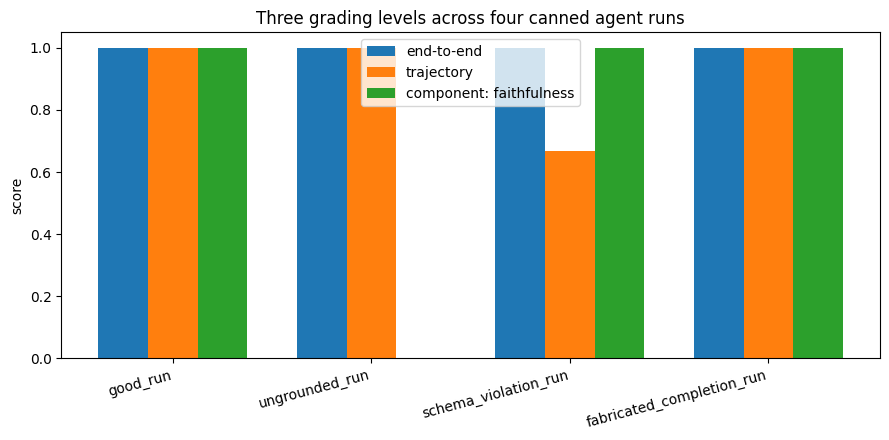

In [8]:
%matplotlib inline
labels = [g["id"] for g in GRADES]
end_to_end_scores = [g["end_to_end"] for g in GRADES]
trajectory_scores = [g["trajectory"] for g in GRADES]
faithfulness_scores = [g["component_faithfulness"] for g in GRADES]

x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width, end_to_end_scores, width, label="end-to-end")
ax.bar(x, trajectory_scores, width, label="trajectory")
ax.bar(x + width, faithfulness_scores, width, label="component: faithfulness")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Three grading levels across four canned agent runs")
ax.legend()
plt.tight_layout()
plt.show()

*The fabricated-completion run passes end-to-end (its keyword check is satisfied) while failing faithfulness -- exactly the failure that hides on a dashboard built only from end-to-end scores.*

## E. Step 4 -- your best tests are already in your logs

A `TRACE_LOG` of complete runs is mined for the four archetypes the article calls out: a clean baseline, a run where a tool came back empty, and (when live) a run that needed a real completion signal. Each becomes a `TASK_SUITE`-shaped case, the same shape notebook 27b already uses.

Then the verifier is checked before it is trusted: feed `verify_completion` one clearly good trace and one plausible-but-wrong trace, and assert it tells them apart. If it can not, the rubric is broken, not the agent.

In [9]:
TRACE_LOG = list(CANNED_RUNS.items())

def mine_eval_cases(trace_log):
    cases = []
    for name, run in trace_log:
        if name == "good_run":
            archetype = "clean_baseline"
        elif "No results found." in concat_tool_outputs(run["trajectory"]):
            archetype = "empty_tool_return"
        elif cites_phantom_source(run):
            archetype = "fabricated_citation"
        elif schema_errors_for(run):
            archetype = "schema_violation"
        else:
            archetype = "other"
        cases.append({"id": name, "archetype": archetype, "prompt": run["final_answer"],
                      "required_tools": run["required_tools"], "forbidden_tools": run["forbidden_tools"],
                      "answer_check": run["answer_check"]})
    return cases

MINED_SUITE = mine_eval_cases(TRACE_LOG)
for case in MINED_SUITE:
    print(f"{case['id']:26s} archetype={case['archetype']}")

# Verify the verifier: one known-good trace and one plausible-wrong trace must come out different.
known_good = verify_completion(CANNED_RUNS["good_run"])
plausible_wrong = verify_completion(CANNED_RUNS["fabricated_completion_run"])
assert known_good["verified_completion"] is True, "verifier failed to pass a known-good run"
assert plausible_wrong["verified_completion"] is False, "verifier failed to catch a plausible-wrong run"
print("Verifier separates known-good from plausible-wrong. Trustworthy for gating.")

good_run                   archetype=clean_baseline
ungrounded_run             archetype=empty_tool_return
schema_violation_run       archetype=schema_violation
fabricated_completion_run  archetype=fabricated_citation
Verifier separates known-good from plausible-wrong. Trustworthy for gating.


## F. Step 5 -- pin the judge or lose the month

Two rubric versions score the *same* padded, ungrounded answer. `grounding-v1` asks for a vague quality rating and tends to reward length and confident phrasing. `grounding-v2` is a one-line, observable-outcome rubric ("what fraction of claims are supported") that does not have a length lever to reward. Every printed `Verdict` carries its `judge_id` and `rubric_version` -- without both, a score is unreproducible the moment either changes.

The self-report cell demonstrates why intrinsic self-correction is not enough: asking a model to grade its own fabricated answer with no external grounding tends to score it fine, which is exactly why `MODEL_SELF_REPORT` gets the least weight of any evidence source in Section G.

In [10]:
PADDED_UNGROUNDED_ANSWER = (
    "That is a great question! Let me think about this carefully. Multiple sources converge on "
    "this point, and after weighing all the considerations thoroughly, the most likely rate is "
    "around 7 percent, though further research could of course refine this estimate."
)

judge_v1 = JudgeConfig(
    judge_id=TEACH_MODEL, rubric_version="grounding-v1",
    rubric="Rate how good this answer is on a scale of 0 to 10, considering thoroughness.",
    call_fn=lambda p: ask(p, system="Rate how good this answer is on a scale of 0 to 10, considering thoroughness. Reply with ONLY the number.", max_tokens=5),
)
judge_v2 = JudgeConfig(
    judge_id=TEACH_MODEL, rubric_version="grounding-v2",
    rubric="Score = fraction of factual claims in the answer directly supported by the provided context, 0-10. Never reward length.",
    call_fn=lambda p: ask(p, system="Score = fraction of factual claims in the answer directly supported by the provided context, 0-10. Never reward length or confident phrasing alone. Reply with ONLY the number.", max_tokens=5),
)

prompt = f"Context: (no supporting source was retrieved)\nAnswer: {PADDED_UNGROUNDED_ANSWER}\nRating (0-10):"
v1 = judge_verdict(judge_v1, prompt)
v2 = judge_verdict(judge_v2, prompt)
print("v1 (vague rubric):     ", v1)
print("v2 (observable-outcome):", v2)

v1 (vague rubric):      Verdict(score=0.0, passed=False, judge_id='claude-haiku-4-5-20251001', rubric_version='grounding-v1', rubric='Rate how good this answer is on a scale of 0 to 10, considering thoroughness.', rationale='[skipped: no ANTHROPIC_API_KEY]')
v2 (observable-outcome): Verdict(score=0.0, passed=False, judge_id='claude-haiku-4-5-20251001', rubric_version='grounding-v2', rubric='Score = fraction of factual claims in the answer directly supported by the provided context, 0-10. Never reward length.', rationale='[skipped: no ANTHROPIC_API_KEY]')


In [11]:
# Self-report: ask the model to grade its OWN fabricated-completion answer, no external grounding.
fabricated = CANNED_RUNS["fabricated_completion_run"]
self_report_prompt = f"You previously answered: {fabricated['final_answer']!r}\nRate your own answer's accuracy, 0-10:"
self_report = ask(self_report_prompt, system="Reply with ONLY the number.", max_tokens=5)
print("Self-report on a fabricated answer:", self_report)

self_report_evidence = Evidence(
    source=EvidenceSource.MODEL_SELF_REPORT,
    passed=True,   # a self-report on a fabrication usually comes back looking fine -- see notebook's Step 5
    detail=f"model self-report: {self_report!r}",
)
print(self_report_evidence)
print("This is exactly why MODEL_SELF_REPORT carries the lowest weight in EVIDENCE_WEIGHTS.")

Self-report on a fabricated answer: [skipped: no ANTHROPIC_API_KEY]
Evidence(source=<EvidenceSource.MODEL_SELF_REPORT: 'model_self_report'>, passed=True, detail="model self-report: '[skipped: no ANTHROPIC_API_KEY]'")
This is exactly why MODEL_SELF_REPORT carries the lowest weight in EVIDENCE_WEIGHTS.


## G. Step 6 -- open the gate on blast radius, not on confidence

Three simulated changes, sorted by how expensive a mistake would be to undo, each carrying an `Evidence` bundle drawn from the checks above. `MergeGate` starts in shadow mode: it scores every change but does not merge any of them, and `disagreement_rate` tracks how often the gate's call would have differed from a human reviewer's -- the number to watch before ever flipping `shadow_mode` off.

The irreversible lane is a structural rule, not a threshold: `MergeGate.evaluate` checks `auto_open` before it ever looks at the evidence score, so a perfect score cannot open it.

In [12]:
gate = MergeGate()

CHANGES = [
    {"name": "docs_typo_fix", "lane": BlastRadius.REVERSIBLE_CONTAINED, "evidence": [
        Evidence(EvidenceSource.DETERMINISTIC_CHECK, True, "lint + tests pass"),
        Evidence(EvidenceSource.EVAL_TRAJECTORY, True, "clean 1-step trajectory"),
    ]},
    {"name": "shared_config_change", "lane": BlastRadius.REVERSIBLE_WIDE, "evidence": [
        Evidence(EvidenceSource.DETERMINISTIC_CHECK, True, "schema valid"),
        Evidence(EvidenceSource.EVAL_TRAJECTORY, True, "trajectory score 0.83"),
        Evidence(EvidenceSource.ROLLBACK_HISTORY, False, "2 of the last 5 changes to this file were reverted"),
        Evidence(EvidenceSource.MODEL_SELF_REPORT, True, "model reports high confidence"),
    ]},
    {"name": "prod_data_deletion", "lane": BlastRadius.IRREVERSIBLE, "evidence": [
        Evidence(EvidenceSource.DETERMINISTIC_CHECK, True, "all checks green"),
        Evidence(EvidenceSource.EVAL_TRAJECTORY, True, "clean trajectory"),
        Evidence(EvidenceSource.MODEL_SELF_REPORT, True, "model reports 99 percent confidence"),
    ]},
]

for change in CHANGES:
    decision = gate.evaluate(change["lane"], change["evidence"])
    print(f"{change['name']:22s} lane={change['lane'].value:22s} opened={decision.opened!s:6s} evidence_score={decision.evidence_score:.2f}")

# A human reviewer's calls on the same three changes, in order.
human_calls = [True, False, False]
print(f"\nGate-vs-human disagreement rate: {gate.disagreement_rate(human_calls):.0%}  (keep shadow_mode on while this is meaningfully above zero)")

docs_typo_fix          lane=reversible_contained   opened=True   evidence_score=1.00
shared_config_change   lane=reversible_wide        opened=True   evidence_score=0.85
prod_data_deletion     lane=irreversible           opened=False  evidence_score=1.00

Gate-vs-human disagreement rate: 33%  (keep shadow_mode on while this is meaningfully above zero)


In [13]:
# CI tie-in: notebook 27b's Exercise 3 sketched "gate on correctness, warn on quality" --
# this is that split expressed as evidence for the gate, feeding notebook 33's CI pipeline.
baseline_solve_rate, current_solve_rate = 0.83, 0.83
baseline_trajectory, current_trajectory = 0.90, 0.75

solve_rate_evidence = Evidence(
    source=EvidenceSource.DETERMINISTIC_CHECK,
    passed=current_solve_rate >= 0.9 * baseline_solve_rate,
    detail=f"solve rate {current_solve_rate:.0%} vs baseline {baseline_solve_rate:.0%} (floor: 90% of baseline)",
)
print(solve_rate_evidence, "-- BLOCKS the merge if failed")

if current_trajectory < baseline_trajectory:
    print(f"WARNING: trajectory score regressed {baseline_trajectory:.2f} -> {current_trajectory:.2f} -- logged, does not block")
print("\nThis is the decision policy; notebook 33 runs the actual CI pipeline around it.")

Evidence(source=<EvidenceSource.DETERMINISTIC_CHECK: 'deterministic_check'>, passed=True, detail='solve rate 83% vs baseline 83% (floor: 90% of baseline)') -- BLOCKS the merge if failed

This is the decision policy; notebook 33 runs the actual CI pipeline around it.


## Exercises

**Exercise 1 (Warm-up):** Raise `REVERSIBLE_WIDE`'s `evidence_floor` in `DEFAULT_LANES` (or pass a custom `LanePolicy` to `MergeGate`) and raise `grounding_floor` in a call to `verdict_to_action`. Re-run Section C and Section G. Which change flips first, and which single `Evidence` source is it hinging on?

**Exercise 2 (Apply):** Implement `panel_verdict(judges, prompt)` that runs every `JudgeConfig` in `judges`, takes a majority vote on `passed`, and returns a merged `Verdict` whose `judge_id` records the whole panel (not just one judge) -- escalate instead of silently averaging when the panel disagrees.

**Exercise 3 (Extend):** Implement `ci_evidence(current_results, baseline_results)` that returns a blocking `Evidence` when solve rate drops below 90% of baseline and a separate, non-blocking warning for a trajectory or cost regression -- the exact split notebook 27b's Exercise 3 sketched in comments. Feed the blocking evidence through `MergeGate` for a `REVERSIBLE_WIDE` change and check whether it still opens.

In [14]:
# Exercise 1: Warm-up
# Task: raise REVERSIBLE_WIDE's evidence_floor and verdict_to_action's grounding_floor; re-run C and G.
# Hint: gate.policies[BlastRadius.REVERSIBLE_WIDE].evidence_floor = ...

# YOUR CODE HERE


# Exercise 2: Apply
# Task: implement panel_verdict(judges, prompt) with majority vote and escalate-on-disagreement.
# Hint: call judge_verdict once per judge, count how many have .passed True, decide by majority.

# YOUR CODE HERE


# Exercise 3: Extend
# Task: implement ci_evidence(current_results, baseline_results) per 27b Exercise 3's sketch.
# Hint: one Evidence(DETERMINISTIC_CHECK, ...) for the solve-rate floor; print a warning, do not
# gate, for a trajectory-score regression.

# YOUR CODE HERE

<details>
<summary>Click to reveal solutions</summary>

```python
# Exercise 1
gate.policies[BlastRadius.REVERSIBLE_WIDE].evidence_floor = 0.95
decision = gate.evaluate(BlastRadius.REVERSIBLE_WIDE, CHANGES[1]["evidence"])
print(decision)
# shared_config_change flips from opened=True to opened=False -- it was hinging on
# ROLLBACK_HISTORY (weight 0.3) dragging the weighted score down to exactly the old floor.

# Exercise 2
def panel_verdict(judges, prompt):
    verdicts = [judge_verdict(j, prompt) for j in judges]
    votes_pass = sum(v.passed for v in verdicts)
    majority_passed = votes_pass > len(verdicts) / 2
    disagreement = 0 < votes_pass < len(verdicts)
    panel_id = "panel(" + ",".join(v.judge_id for v in verdicts) + ")"
    avg_score = np.mean([v.score for v in verdicts])
    return Verdict(score=avg_score, passed=majority_passed and not disagreement,
                   judge_id=panel_id, rubric_version="panel-v1",
                   rubric="majority vote across panel; escalate on disagreement",
                   rationale=f"votes_pass={votes_pass}/{len(verdicts)}")

print(panel_verdict([judge_v1, judge_v2], prompt))

# Exercise 3
def ci_evidence(current_results, baseline_results):
    solve_rate_ok = current_results["solve_rate"] >= 0.9 * baseline_results["solve_rate"]
    blocking = Evidence(EvidenceSource.DETERMINISTIC_CHECK, solve_rate_ok,
                         f"solve rate {current_results['solve_rate']:.0%} vs 90% of baseline")
    if current_results["trajectory"] < baseline_results["trajectory"]:
        print(f"WARNING: trajectory regressed {baseline_results['trajectory']:.2f} -> {current_results['trajectory']:.2f}")
    return blocking

ev = ci_evidence({"solve_rate": 0.83, "trajectory": 0.75}, {"solve_rate": 0.83, "trajectory": 0.90})
print(gate.evaluate(BlastRadius.REVERSIBLE_WIDE, [ev]))
```
</details>

## Key Takeaways
- A judge's score is partly a measurement of the judge -- cross-family judging, panels for high-stakes calls, and routing objective checks to code (not a judge) are the three rules that keep this from laundering a guess into a number.
- A verdict that does not change what runs next is a report, not a gate -- `verdict_to_action` maps every verdict to a structural action (proceed, retry, reject a handoff, block an edge, quarantine, end the run).
- Grade at three levels -- end-to-end, trajectory, component -- because each catches a different failure class; faithfulness is the one that hides, since a fabricated fact can still pass every other metric on the board.
- Your production traces already contain your best eval cases; mine them for archetypes (clean, corrected, empty-return, timeout), and always verify the verifier on one known-good and one plausible-wrong case before trusting it.
- Evidence priority is structural, not a vibe: deterministic checks outrank trajectory evals, which outrank rollback history, which outranks the model's own self-report -- and an irreversible lane never auto-opens regardless of score.

## What's Next
Tier 8's `33_ci_for_ai` runs a version of this gate as an actual CI pipeline -- the regression-gate mechanics this notebook's decision policy is designed to sit in front of.